# Analisis Probabilitas Hujan di Nusa Tenggara Timur (NTT)
### Periode 1985 – 2015 | Data ERA5 Reanalysis × ONI NOAA

---

## Latar Belakang

Nusa Tenggara Timur (NTT) merupakan salah satu wilayah di Indonesia yang memiliki pola hujan yang sangat dipengaruhi oleh kondisi iklim global, khususnya fenomena **El Niño – La Niña** yang diukur melalui indeks **ONI (*Oceanic Niño Index*)**.

- **El Niño** (ONI tinggi, > +0.5) cenderung menyebabkan **musim kering yang lebih panjang** di NTT.
- **La Niña** (ONI rendah, < -0.5) cenderung menyebabkan **curah hujan yang lebih tinggi** dari normal.

---

## Tujuan Analisis

Notebook ini bertujuan untuk:

1. **Memproses data curah hujan** dari ERA5 Reanalysis dan data indeks ONI dari NOAA
2. **Menghitung probabilitas hujan** per musim dan per titik grid spasial di wilayah NTT
3. **Menganalisis korelasi** antara probabilitas hujan dan indeks ONI per musim
4. **Memvisualisasikan sebaran spasial** probabilitas hujan seluruh wilayah NTT
5. **Mengekspor data** untuk digunakan di dashboard interaktif

---

## Pembagian Musim

Analisis ini menggunakan 4 kelompok musim berdasarkan bulan:

| Kode | Bulan | Keterangan |
|------|-------|------------|
| **JFM** | Januari – Maret | Puncak musim hujan |
| **AMJ** | April – Juni | Transisi hujan ke kering |
| **JAS** | Juli – September | Musim kering |
| **OND** | Oktober – Desember | Awal musim hujan |

---

## Definisi Probabilitas Hujan

Probabilitas hujan dihitung dengan cara:
- Setiap hari dikategorikan: **hujan** jika curah hujan > 0.5 mm, **tidak hujan** jika ≤ 0.5 mm
- Probabilitas per musim = persentase hari hujan dari total hari dalam musim tersebut

**Contoh:** Jika dalam musim JFM (90 hari) ada 54 hari hujan → probabilitas = 60%

---
## Bagian 1: Persiapan — Import Library

**Tujuan:** Memuat semua pustaka (library) Python yang diperlukan untuk analisis data, visualisasi, dan pengolahan data spasial.

In [143]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

---
## Bagian 2: Load dan Pembersihan Data ONI

**Tujuan:** Membaca data indeks ONI dari NOAA, membuang kolom musim yang tidak digunakan, dan memfilter hanya periode 1985–2015.

**Kolom yang dipertahankan:** `Year`, `JFM`, `AMJ`, `JAS`, `OND`  
**Kolom yang dihapus:** `DJF`, `FMA`, `MAM`, `MJJ`, `JJA`, `ASO`, `SON`, `NDJ` (musim tumpang tindih yang tidak dipakai)

In [144]:
data = pd.read_csv('C:/Metklim pbl/ONI.csv')
data

,Year,DJF,JFM,FMA,MAM,AMJ,MJJ,JJA,JAS,ASO,SON,OND,NDJ
0,1950,-1.400000,-1.200000,-1.100000,-1.200000,-1.100000,-0.900000,-0.600000,-0.600000,-0.500000,-0.600000,-0.700000,-0.800000
1,1951,-0.800000,-0.600000,-0.200000,0.200000,0.200000,0.400000,0.500000,0.700000,0.800000,0.900000,0.700000,0.600000
2,1952,0.500000,0.400000,0.400000,0.400000,0.400000,0.200000,0.000000,0.100000,0.200000,0.200000,0.200000,0.300000
3,1953,0.500000,0.600000,0.700000,0.700000,0.700000,0.700000,0.700000,0.700000,0.800000,0.800000,0.800000,0.700000
4,1954,0.700000,0.400000,0.000000,-0.400000,-0.500000,-0.500000,-0.500000,-0.700000,-0.700000,-0.600000,-0.500000,-0.500000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
63,2013,-0.400000,-0.400000,-0.300000,-0.200000,-0.200000,-0.200000,-0.300000,-0.300000,-0.200000,-0.300000,-0.300000,-0.300000
64,2014,-0.500000,-0.500000,-0.400000,-0.200000,-0.100000,0.000000,-0.100000,0.000000,0.100000,0.400000,0.500000,0.600000
65,2015,0.600000,0.500000,0.600000,0.700000,0.800000,1.000000,1.200000,1.400000,1.700000,2.000000,2.200000,2.300000
66,2016,2.200000,2.000000,1.600000,1.100000,0.600000,0.100000,-0.300000,-0.600000,-0.800000,-0.800000,-0.800000,-0.700000


In [145]:
data = data.drop(columns=['DJF', 'FMA', 'MAM', 'MJJ','ASO', 'JJA', 'SON', 'NDJ'])
data

,Year,JFM,AMJ,JAS,OND
0,1950,-1.200000,-1.100000,-0.600000,-0.700000
1,1951,-0.600000,0.200000,0.700000,0.700000
2,1952,0.400000,0.400000,0.100000,0.200000
3,1953,0.600000,0.700000,0.700000,0.800000
4,1954,0.400000,-0.500000,-0.700000,-0.500000
...,...,...,...,...,...
63,2013,-0.400000,-0.200000,-0.300000,-0.300000
64,2014,-0.500000,-0.100000,0.000000,0.500000
65,2015,0.500000,0.800000,1.400000,2.200000
66,2016,2.000000,0.600000,-0.600000,-0.800000


In [146]:
data = data[
    (data['Year'] >= 1985) &
    (data['Year'] <= 2015)
]
data

,Year,JFM,AMJ,JAS,OND
35,1985,-0.700000,-0.700000,-0.400000,-0.200000
36,1986,-0.400000,-0.100000,0.400000,1.000000
37,1987,1.200000,0.900000,1.600000,1.200000
38,1988,0.500000,-0.800000,-1.100000,-1.700000
39,1989,-1.400000,-0.600000,-0.300000,-0.200000
40,1990,0.200000,0.200000,0.300000,0.400000
41,1991,0.300000,0.400000,0.700000,1.200000
42,1992,1.500000,1.000000,0.200000,-0.100000
43,1993,0.300000,0.800000,0.200000,0.100000
44,1994,0.100000,0.400000,0.400000,0.900000


---
## Bagian 3: Konversi Data ERA5 dari Format NetCDF ke CSV

**Tujuan:** Mengubah data curah hujan ERA5 (format `.nc` / NetCDF) menjadi format tabel CSV agar bisa diproses lebih lanjut dengan pandas.

> **Catatan:** Cell ini hanya perlu dijalankan **sekali**. File `rainfallNTT.csv` akan tersimpan dan bisa langsung dipakai di cell berikutnya tanpa perlu dikonversi ulang.

In [147]:
import xarray as xr
DS = xr.open_dataset("data_stream-oper_stepType-accum.nc")
DS.to_dataframe().to_csv("rainfallNTT.csv")

---
## Bagian 4: Load Data Curah Hujan ERA5

**Tujuan:** Membaca data curah hujan hasil konversi, lalu menyimpan data ONI ke variabel terpisah agar tidak tercampur.

In [148]:
dataONI = data

In [149]:
dataCH = pd.read_csv('C:/Metklim pbl/rainfallNTT.csv')
dataCH

,valid_time,latitude,longitude,tp,number,expver
0,1985-01-01,-8.000000,118.000000,0.000000,0,1
1,1985-01-01,-8.000000,118.250000,0.000007,0,1
2,1985-01-01,-8.000000,118.500000,0.000011,0,1
3,1985-01-01,-8.000000,118.750000,0.000000,0,1
4,1985-01-01,-8.000000,119.000000,0.000000,0,1
...,...,...,...,...,...,...
5264725,2015-12-31,-11.500000,124.500000,0.000004,0,1
5264726,2015-12-31,-11.500000,124.750000,0.000003,0,1
5264727,2015-12-31,-11.500000,125.000000,0.000000,0,1
5264728,2015-12-31,-11.500000,125.250000,0.000000,0,1


**Tujuan:** Menghapus kolom `number` dan `expver` yang merupakan metadata teknis ERA5 dan tidak dibutuhkan untuk analisis.

In [150]:
dataCH = dataCH.drop(columns=['number','expver'])
dataCH

,valid_time,latitude,longitude,tp
0,1985-01-01,-8.000000,118.000000,0.000000
1,1985-01-01,-8.000000,118.250000,0.000007
2,1985-01-01,-8.000000,118.500000,0.000011
3,1985-01-01,-8.000000,118.750000,0.000000
4,1985-01-01,-8.000000,119.000000,0.000000
...,...,...,...,...
5264725,2015-12-31,-11.500000,124.500000,0.000004
5264726,2015-12-31,-11.500000,124.750000,0.000003
5264727,2015-12-31,-11.500000,125.000000,0.000000
5264728,2015-12-31,-11.500000,125.250000,0.000000


---
## Bagian 5: Eksplorasi Awal Data

**Tujuan:** Memahami struktur kedua dataset — tipe data tiap kolom, jumlah baris, dan ada tidaknya nilai yang hilang (*missing values*).

In [151]:
dataCH.info()
dataONI.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5264730 entries, 0 to 5264729
Data columns (total 4 columns):
 #   Column      Dtype  
---  ------      -----  
 0   valid_time  object 
 1   latitude    float64
 2   longitude   float64
 3   tp          float64
dtypes: float64(3), object(1)
memory usage: 160.7+ MB
<class 'pandas.core.frame.DataFrame'>
Index: 31 entries, 35 to 65
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Year    31 non-null     int64  
 1   JFM     31 non-null     float64
 2   AMJ     31 non-null     float64
 3   JAS     31 non-null     float64
 4   OND     31 non-null     float64
dtypes: float64(4), int64(1)
memory usage: 1.5 KB


**Tujuan:** Mengkonversi satuan curah hujan dari meter (satuan asli ERA5) ke **milimeter (mm)** yang lebih umum digunakan dalam meteorologi.

> **Rumus:** 1 m = 1000 mm, jadi kolom `tp` dikalikan 1000.

In [152]:
dataCH['tp'] = dataCH['tp'] * 1000

**Tujuan:** Menampilkan statistik deskriptif (nilai minimum, maksimum, rata-rata, standar deviasi, dsb.) untuk masing-masing dataset sebagai gambaran umum sebaran data.

In [153]:
pd.set_option('display.float_format', '{:.6f}'.format)

dataCH.describe()

,latitude,longitude,tp
count,5264730.000000,5264730.000000,5264730.000000
mean,-9.750000,121.750000,0.116732
std,1.080124,2.236068,0.413931
min,-11.500000,118.000000,0.000000
25%,-10.750000,119.750000,0.000000
50%,-9.750000,121.750000,0.002861
75%,-8.750000,123.750000,0.051498
max,-8.000000,125.500000,31.322480


In [154]:
dataONI.describe()

,Year,JFM,AMJ,JAS,OND
count,31.000000,31.000000,31.000000,31.000000,31.000000
mean,2000.000000,-0.041935,0.019355,0.041935,0.045161
std,9.092121,0.848832,0.521804,0.735198,1.049393
min,1985.000000,-1.400000,-0.900000,-1.200000,-1.700000
25%,1992.500000,-0.600000,-0.250000,-0.450000,-0.700000
50%,2000.000000,0.000000,0.000000,0.000000,-0.100000
75%,2007.500000,0.500000,0.400000,0.400000,0.900000
max,2015.000000,1.800000,1.000000,1.700000,2.300000


---
## Bagian 6: Visualisasi Time Series Indeks ONI

**Tujuan:** Melihat pola indeks ONI dari tahun 1985 hingga 2015 untuk setiap musim. Garis putus-putus di angka 0 memisahkan kondisi El Niño (di atas 0) dan La Niña (di bawah 0).

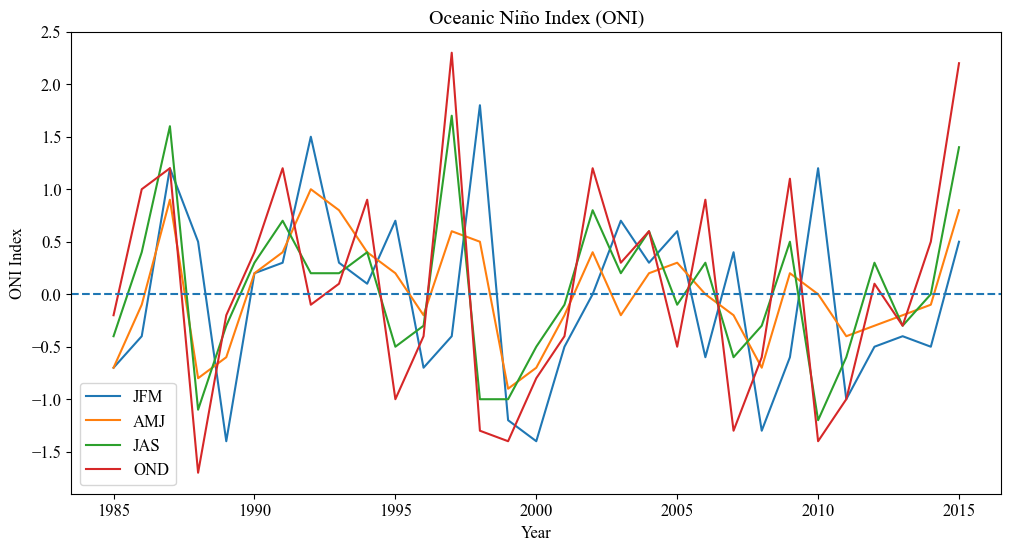

In [155]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(dataONI['Year'], dataONI['JFM'], label='JFM')
plt.plot(dataONI['Year'], dataONI['AMJ'], label='AMJ')
plt.plot(dataONI['Year'], dataONI['JAS'], label='JAS')
plt.plot(dataONI['Year'], dataONI['OND'], label='OND')

plt.axhline(0, linestyle='--')

plt.xlabel('Year')
plt.ylabel('ONI Index')
plt.title('Oceanic Niño Index (ONI)')
plt.legend()

plt.show()

---
## Bagian 7: Pembuatan Kategori Hujan

**Tujuan:** Mengubah nilai curah hujan (mm) menjadi kategori biner:
- `1` = **Hujan** → curah hujan > 0.5 mm
- `0` = **Tidak Hujan** → curah hujan ≤ 0.5 mm

Ambang batas 0.5 mm digunakan karena nilai di bawahnya dianggap sebagai embun/noise dan bukan hujan yang signifikan secara meteorologis.

In [156]:
# 1 = hujan dan 0 = tidak hujan
dataCH['Hujan'] = (dataCH['tp'] > 0.5).astype(int)
dataCH

,valid_time,latitude,longitude,tp,Hujan
0,1985-01-01,-8.000000,118.000000,0.000000,0
1,1985-01-01,-8.000000,118.250000,0.007153,0
2,1985-01-01,-8.000000,118.500000,0.010967,0
3,1985-01-01,-8.000000,118.750000,0.000477,0
4,1985-01-01,-8.000000,119.000000,0.000000,0
...,...,...,...,...,...
5264725,2015-12-31,-11.500000,124.500000,0.003815,0
5264726,2015-12-31,-11.500000,124.750000,0.003338,0
5264727,2015-12-31,-11.500000,125.000000,0.000477,0
5264728,2015-12-31,-11.500000,125.250000,0.000000,0


---
## Bagian 8: Perhitungan Probabilitas Hujan per Musim (Agregat Temporal)

**Tujuan:** Menghitung probabilitas hujan rata-rata seluruh NTT per tahun per musim, yang nantinya akan dikorelasikan dengan indeks ONI.

**Langkah-langkah:**
1. Parse kolom waktu `valid_time` menjadi format tanggal
2. Ekstrak tahun dan bulan
3. Kelompokkan bulan menjadi 4 musim (JFM, AMJ, JAS, OND)
4. Hitung rata-rata probabilitas hujan per tahun per musim
5. Ubah format tabel agar tiap musim menjadi kolom tersendiri

In [157]:
import pandas as pd

# datetime
dataCH['valid_time'] = pd.to_datetime(dataCH['valid_time'])

# ubah tp ke mm kalau belum
dataCH['tp'] = dataCH['tp'] * 1000

# kategori hujan
dataCH['Hujan'] = (dataCH['tp'] > 0.5).astype(int)

# ambil tahun dan bulan
dataCH['Year'] = dataCH['valid_time'].dt.year
dataCH['Month'] = dataCH['valid_time'].dt.month

# fungsi musim
def musim(bulan):
    if bulan in [1,2,3]:
        return 'JFM'
    elif bulan in [4,5,6]:
        return 'AMJ'
    elif bulan in [7,8,9]:
        return 'JAS'
    else:
        return 'OND'

# kolom musim
dataCH['Season'] = dataCH['Month'].apply(musim)

# hitung persentase hujan
hasilCH = (
    dataCH.groupby(['Year', 'Season'])['Hujan']
    .mean()
    .mul(100)
    .reset_index()
)

# pivot
hasilCH = hasilCH.pivot(
    index='Year',
    columns='Season',
    values='Hujan'
).reset_index()

# rename kolom
hasilCH = hasilCH.rename(columns={
    'JFM': 'CH_JFM',
    'AMJ': 'CH_AMJ',
    'JAS': 'CH_JAS',
    'OND': 'CH_OND'
})

print(hasilCH)

Season  Year    CH_AMJ    CH_JAS    CH_JFM    CH_OND
0       1985 56.915987 30.867228 82.372760 58.031791
1       1986 59.385561 46.998597 89.240143 53.398784
2       1987 52.520383 35.133240 84.470729 61.425900
3       1988 40.985466 31.262272 86.014416 65.123890
4       1989 61.599905 31.958859 88.074074 47.781674
5       1990 56.036866 30.687237 81.600956 50.479196
6       1991 54.368427 31.234222 83.710872 49.866760
7       1992 58.026704 36.299673 84.121470 56.208509
8       1993 64.220726 45.219729 80.953405 57.716223
9       1994 42.850053 25.039738 87.378734 44.964937
10      1995 62.034739 30.825152 90.511350 63.382422
11      1996 51.700343 35.497896 84.530308 63.854605
12      1997 59.331206 34.254324 79.032258 50.862553
13      1998 66.269644 45.345956 85.596177 75.867228
14      1999 49.885383 26.175783 93.696535 75.624123
15      2000 74.198275 29.048621 91.471110 68.062179
16      2001 60.354484 32.685835 86.712067 65.743338
17      2002 43.372327 27.823749 85.163680 48.

---
## Bagian 9: Penggabungan Data CH dan ONI

**Tujuan:** Menggabungkan tabel probabilitas hujan (`hasilCH`) dengan tabel indeks ONI (`dataONI`) berdasarkan kolom `Year`, sehingga setiap baris merepresentasikan satu tahun dengan nilai CH dan ONI untuk semua musim sekaligus.

In [158]:
gabung = pd.merge(
    hasilCH,
    dataONI,
    on='Year'
)
gabung

,Year,CH_AMJ,CH_JAS,CH_JFM,CH_OND,JFM,AMJ,JAS,OND
0,1985,56.915987,30.867228,82.372760,58.031791,-0.700000,-0.700000,-0.400000,-0.200000
1,1986,59.385561,46.998597,89.240143,53.398784,-0.400000,-0.100000,0.400000,1.000000
2,1987,52.520383,35.133240,84.470729,61.425900,1.200000,0.900000,1.600000,1.200000
3,1988,40.985466,31.262272,86.014416,65.123890,0.500000,-0.800000,-1.100000,-1.700000
4,1989,61.599905,31.958859,88.074074,47.781674,-1.400000,-0.600000,-0.300000,-0.200000
5,1990,56.036866,30.687237,81.600956,50.479196,0.200000,0.200000,0.300000,0.400000
6,1991,54.368427,31.234222,83.710872,49.866760,0.300000,0.400000,0.700000,1.200000
7,1992,58.026704,36.299673,84.121470,56.208509,1.500000,1.000000,0.200000,-0.100000
8,1993,64.220726,45.219729,80.953405,57.716223,0.300000,0.800000,0.200000,0.100000
9,1994,42.850053,25.039738,87.378734,44.964937,0.100000,0.400000,0.400000,0.900000


In [159]:
# ══ NORMALISASI (Min-Max Scaling) ══
# Menyamakan skala CH (0-100%) dan ONI (-3 s/d +3)
# agar bisa dibandingkan dalam satu grafik

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

cols_to_normalize = ['CH_JFM', 'CH_AMJ', 'CH_JAS', 'CH_OND',
                     'JFM', 'AMJ', 'JAS', 'OND']

gabung_norm = gabung.copy()
gabung_norm[cols_to_normalize] = scaler.fit_transform(
    gabung[cols_to_normalize]
)

print("Data setelah normalisasi (skala 0–1):")
print(gabung_norm.head())

Data setelah normalisasi (skala 0–1):
   Year   CH_AMJ   CH_JAS   CH_JFM   CH_OND      JFM      AMJ      JAS  \
0  1985 0.479650 0.247221 0.227799 0.463583 0.218750 0.105263 0.275862   
1  1986 0.554006 0.745344 0.696106 0.324241 0.312500 0.421053 0.551724   
2  1987 0.347303 0.378952 0.370865 0.565664 0.812500 0.947368 0.965517   
3  1988 0.000000 0.259420 0.476134 0.676884 0.593750 0.052632 0.034483   
4  1989 0.620677 0.280930 0.616588 0.155301 0.000000 0.157895 0.310345   

       OND  
0 0.375000  
1 0.675000  
2 0.725000  
3 0.000000  
4 0.375000  


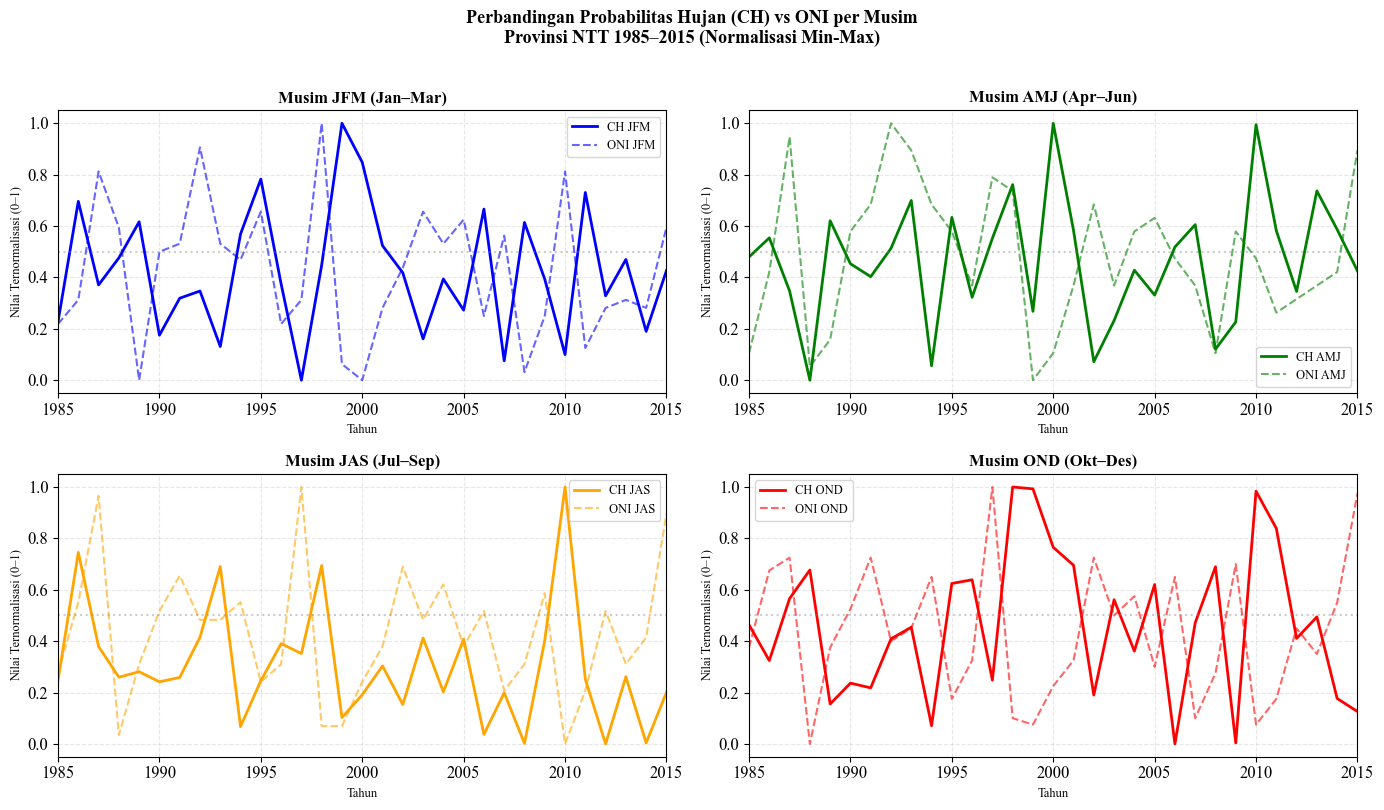

In [160]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

musim_list  = ['JFM', 'AMJ', 'JAS', 'OND']
colors      = ['blue', 'green', 'orange', 'red']
label_musim = {'JFM': 'Jan–Mar', 'AMJ': 'Apr–Jun',
               'JAS': 'Jul–Sep', 'OND': 'Okt–Des'}

for i, (s, color) in enumerate(zip(musim_list, colors)):
    ax = axes[i]

    ax.plot(gabung_norm['Year'], gabung_norm[f'CH_{s}'],
            label=f'CH {s}', color=color,
            linewidth=2)

    ax.plot(gabung_norm['Year'], gabung_norm[s],
            label=f'ONI {s}', color=color,
            linewidth=1.5, linestyle='--', alpha=0.6)

    ax.axhline(0.5, linestyle=':', color='gray', alpha=0.4)

    ax.set_title(f'Musim {s} ({label_musim[s]})',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Tahun', fontsize=9)
    ax.set_ylabel('Nilai Ternormalisasi (0–1)', fontsize=9)
    ax.legend(fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.set_xlim(1985, 2015)

fig.suptitle(
    'Perbandingan Probabilitas Hujan (CH) vs ONI per Musim\n'
    'Provinsi NTT 1985–2015 (Normalisasi Min-Max)',
    fontsize=13, fontweight='bold', y=1.01
)

plt.tight_layout()
plt.savefig('CH_vs_ONI_per_musim.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Bagian 10: Analisis Korelasi CH vs ONI — Heatmap

**Tujuan:** Menghitung dan memvisualisasikan kekuatan hubungan antara probabilitas hujan dan indeks ONI untuk setiap musim menggunakan **korelasi Pearson**.

**Cara membaca heatmap:**
- Nilai mendekati **-1** (warna biru gelap) → hubungan **negatif kuat**: saat ONI tinggi (El Niño), hujan berkurang
- Nilai mendekati **+1** (warna merah gelap) → hubungan **positif kuat**: saat ONI tinggi, hujan bertambah
- Nilai mendekati **0** → **tidak ada hubungan** yang jelas

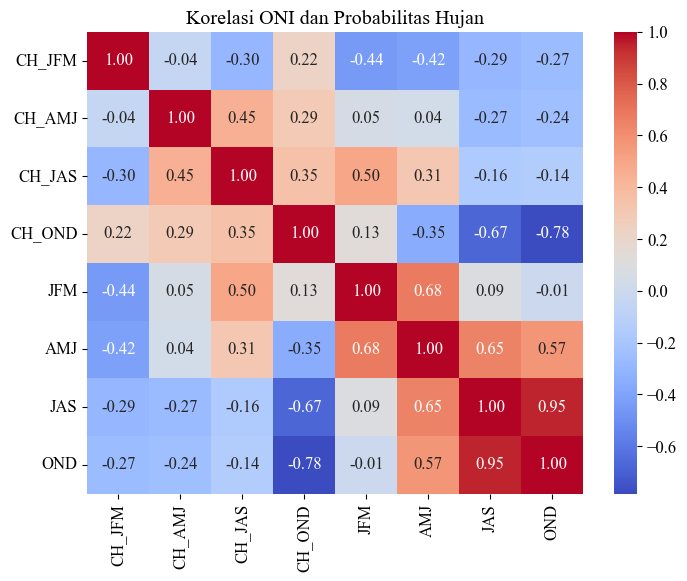

In [161]:
corr_focus = gabung[
    ['CH_JFM', 'CH_AMJ', 'CH_JAS', 'CH_OND',
     'JFM', 'AMJ', 'JAS', 'OND']
].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr_focus,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Korelasi ONI dan Probabilitas Hujan')
plt.show()

---
## Bagian 11: Load Shapefile Batas Wilayah Indonesia

**Tujuan:** Membaca data batas wilayah administrasi Indonesia (format shapefile) yang akan digunakan sebagai overlay pada peta spasial, agar batas kabupaten/provinsi terlihat di atas peta probabilitas hujan.

In [162]:
import geopandas as gpd

indo = gpd.read_file('indonesia_kab.shp')

---
## Bagian 12: Persiapan Data Spasial per Titik Grid

**Tujuan:** Mempersiapkan ulang kolom waktu dan kategori hujan, lalu membuat kolom musim yang akan digunakan untuk agregasi spasial.

> **Catatan:** Langkah ini melengkapi Bagian 8. Perbedaannya adalah Bagian 8 merata-rata seluruh NTT menjadi 1 nilai per tahun per musim (untuk korelasi dengan ONI), sedangkan bagian ini mempertahankan informasi per titik grid (latitude-longitude) untuk keperluan peta.

In [ ]:
import pandas as pd

# datetime
dataCH['valid_time'] = pd.to_datetime(dataCH['valid_time'])

# ubah mm
dataCH['tp'] = dataCH['tp'] * 1000

# kategori hujan
dataCH['Hujan'] = (dataCH['tp'] > 0.5).astype(int)

# tahun dan bulan
dataCH['Year'] = dataCH['valid_time'].dt.year
dataCH['Month'] = dataCH['valid_time'].dt.month

**Tujuan:** Mendefinisikan ulang fungsi pengelompokan bulan ke musim dan menerapkannya ke seluruh data.

In [164]:
def musim(bulan):

    if bulan in [1,2,3]:
        return 'JFM'

    elif bulan in [4,5,6]:
        return 'AMJ'

    elif bulan in [7,8,9]:
        return 'JAS'

    else:
        return 'OND'

dataCH['Season'] = dataCH['Month'].apply(musim)

**Tujuan:** Menghitung probabilitas hujan per kombinasi **Tahun × Musim × Titik Grid (lat-lon)**. Hasilnya adalah tabel `spasial` yang menyimpan persentase hari hujan di setiap titik grid untuk setiap tahun dan musim — inilah data utama untuk membuat peta.

In [165]:
spasial = (
    dataCH.groupby(
        ['Year','Season','latitude','longitude']
    )['Hujan']
    .mean()
    .mul(100)
    .reset_index()
)

---
## Bagian 13: Persiapan Peta — Import Library dan Kombinasi Tahun-Musim

**Tujuan:** Mengimport library untuk visualisasi peta dan membuat daftar semua kombinasi tahun-musim yang tersedia di data, yang akan digunakan sebagai urutan frame (halaman) peta.

In [166]:
import matplotlib.pyplot as plt
import numpy as np

In [167]:
kombinasi = (
    spasial[['Year','Season']]
    .drop_duplicates()
    .values
    .tolist()
)

---
## Bagian 14: Visualisasi Peta Spasial Probabilitas Hujan

**Tujuan:** Membuat peta sebaran spasial probabilitas hujan di seluruh wilayah NTT untuk setiap kombinasi tahun dan musim.

**Cara membaca peta:**
- Warna **biru** → probabilitas hujan **tinggi** (sering hujan)
- Warna **merah/kuning** → probabilitas hujan **rendah** (jarang hujan)
- Setiap halaman gambar menampilkan **20 peta sekaligus** (5 kolom × 4 baris)
- Hasil disimpan otomatis sebagai file gambar PNG (`Frame_1.png`, `Frame_2.png`, dst.)

> **Informasi:** Total kombinasi = 31 tahun × 4 musim = **124 peta**, dibagi menjadi beberapa frame masing-masing 20 peta.

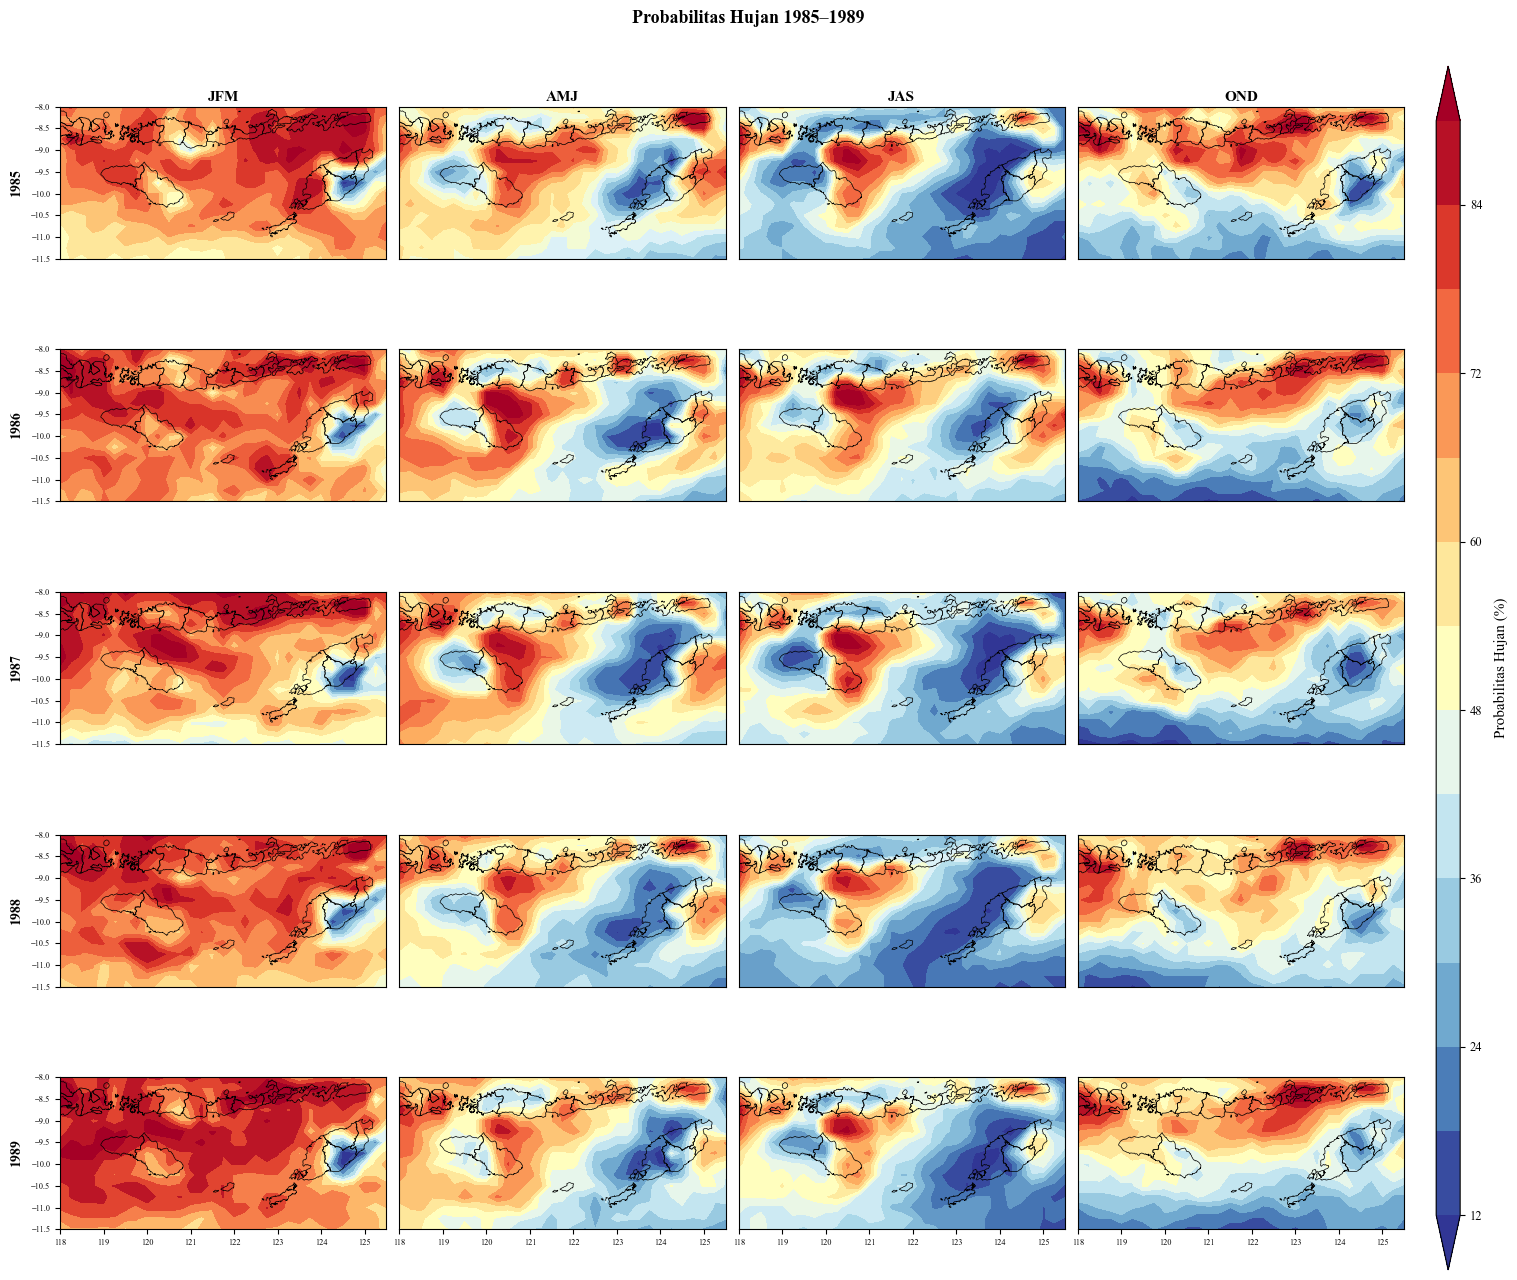

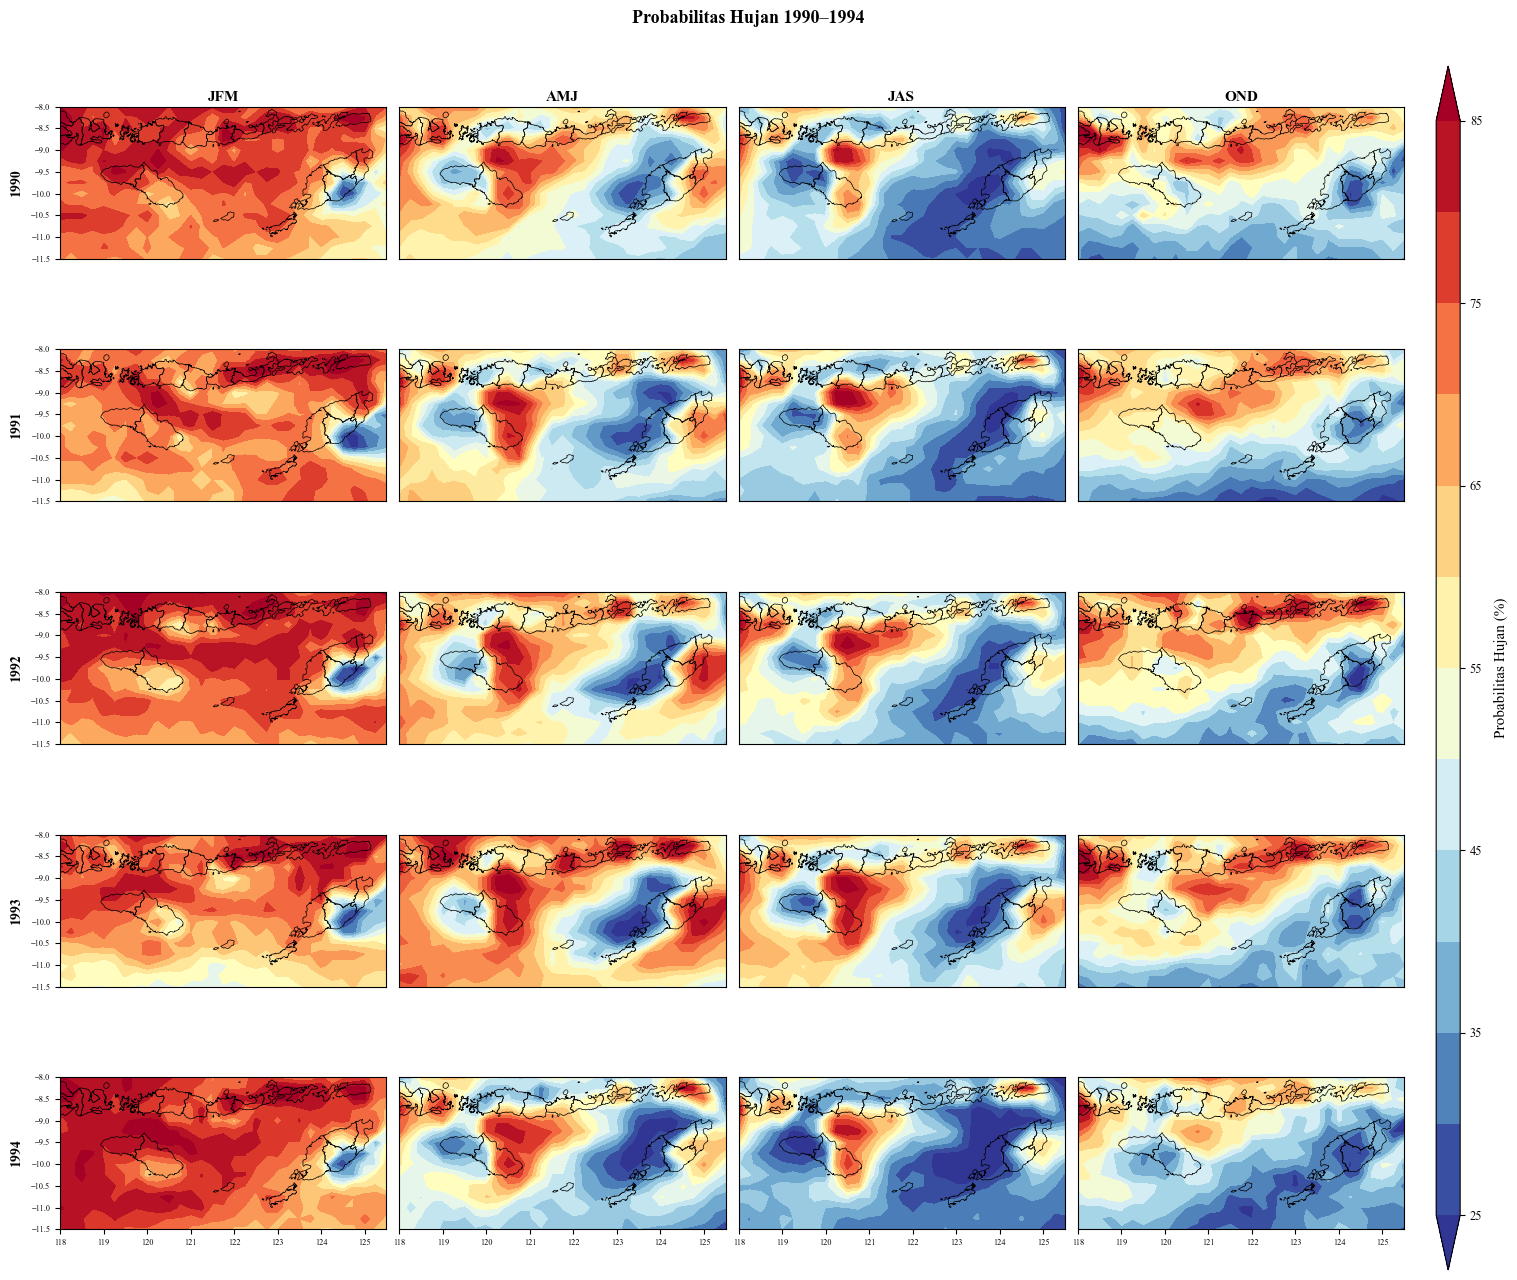

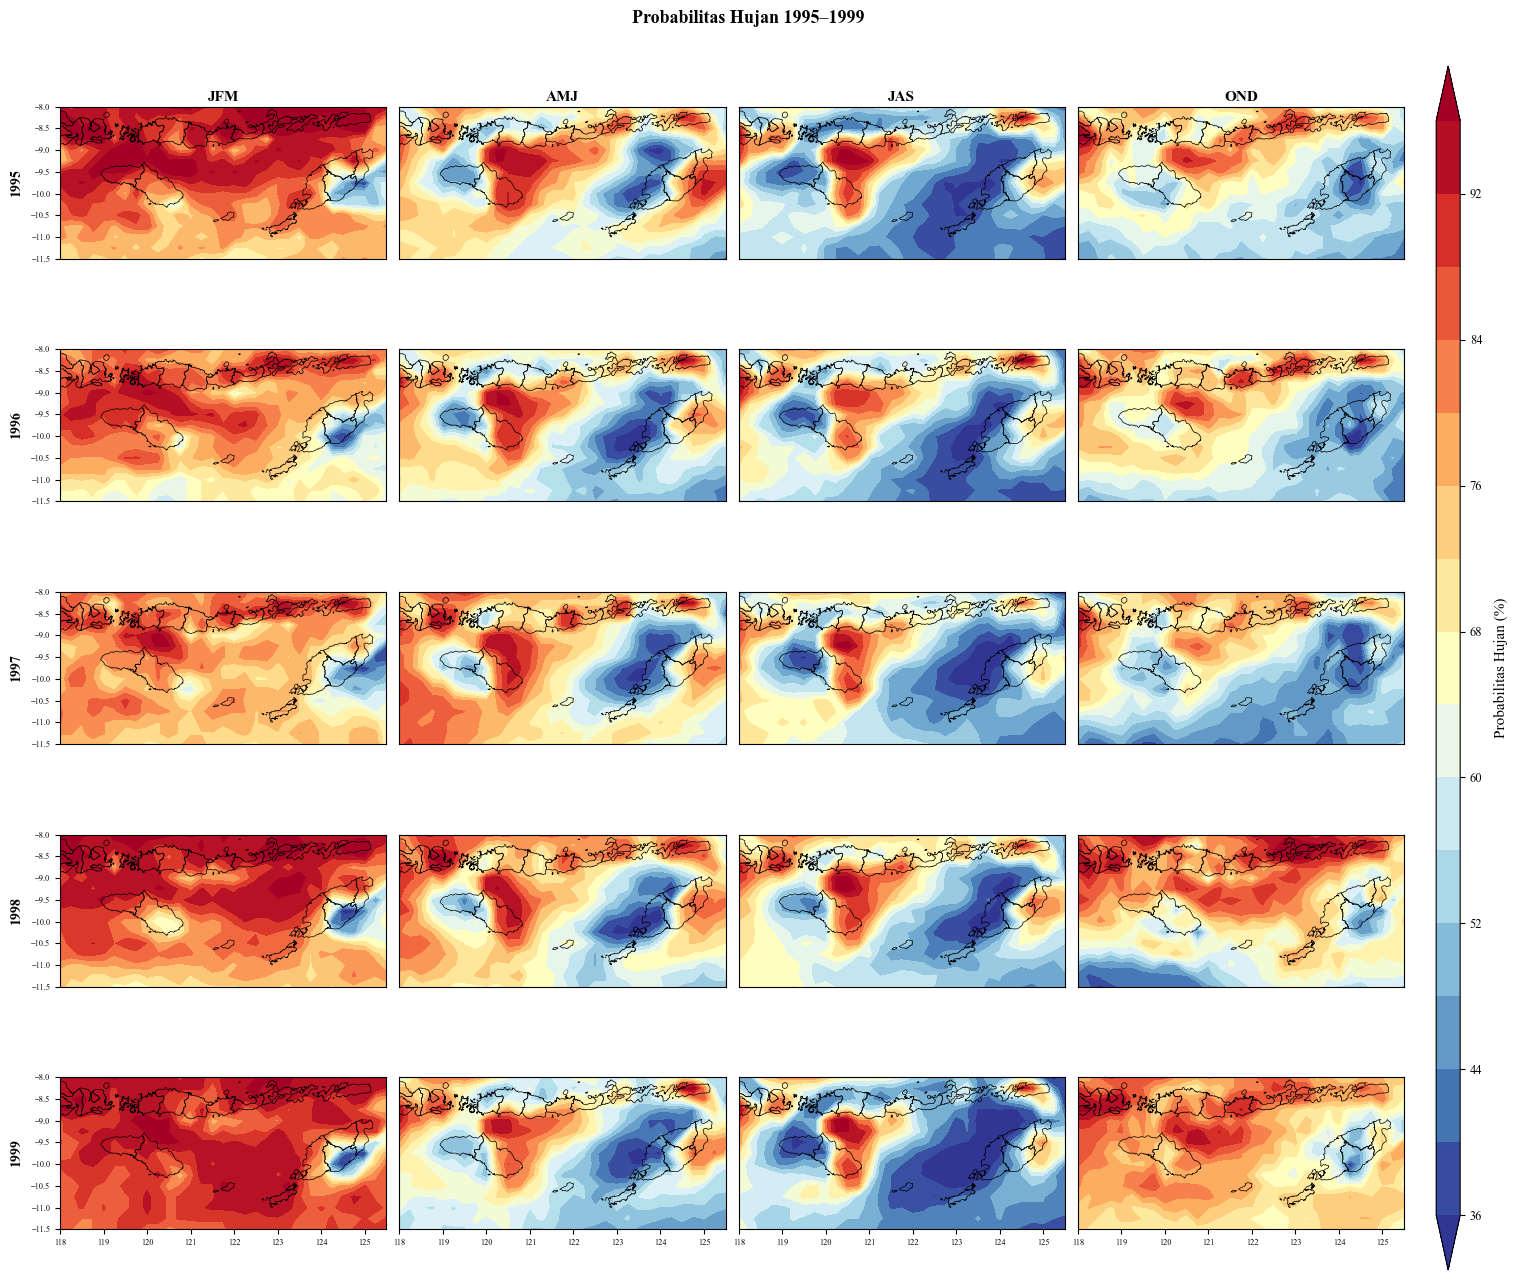

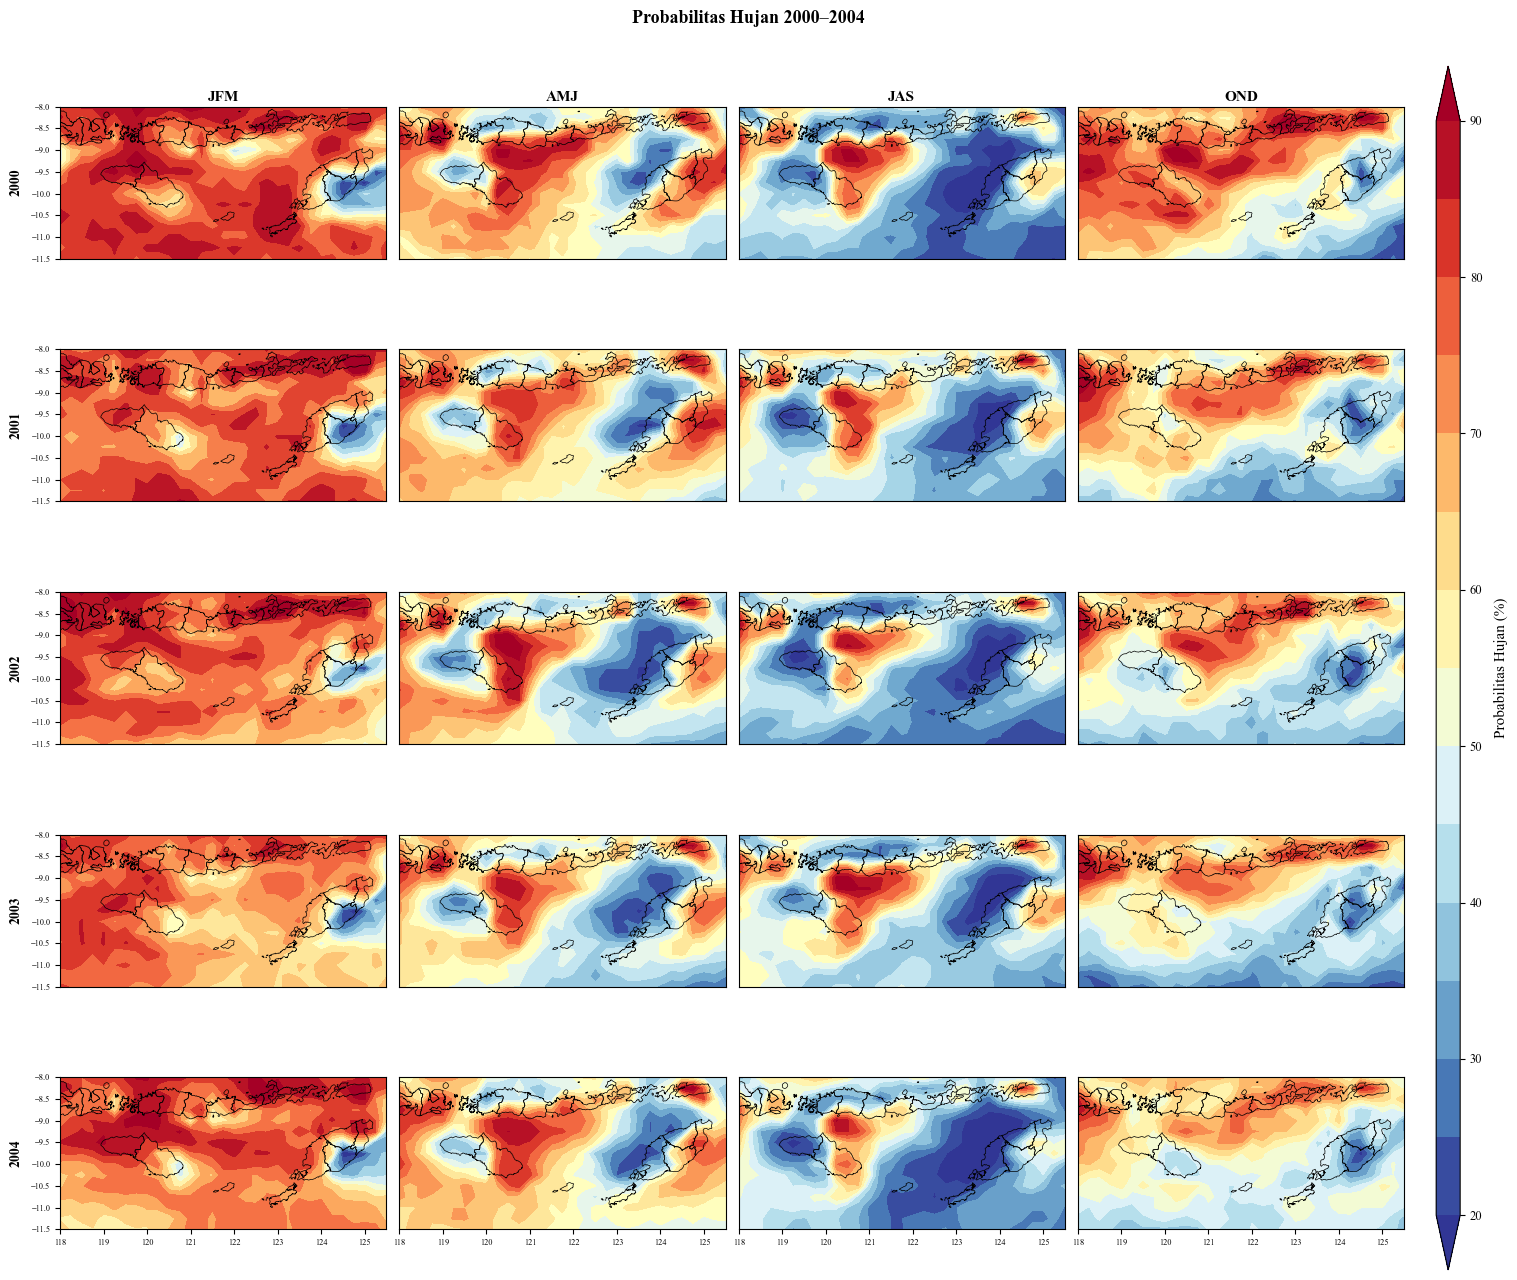

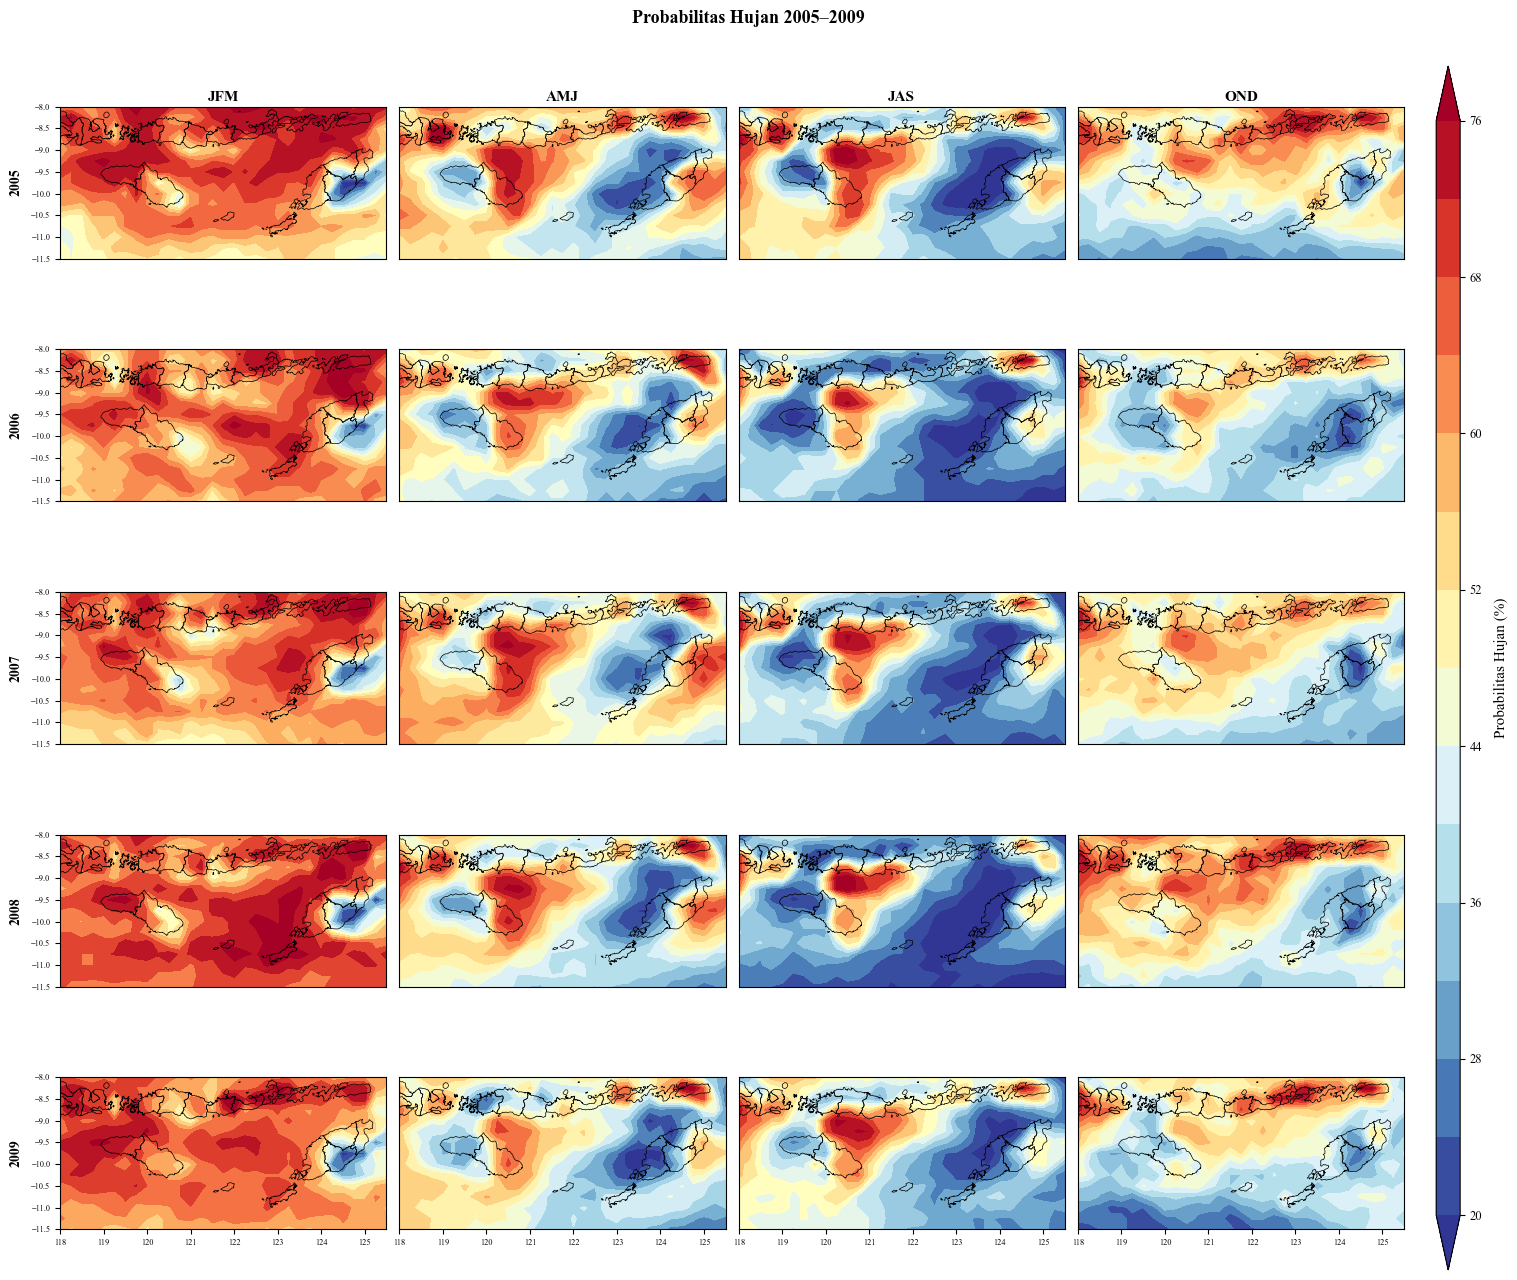

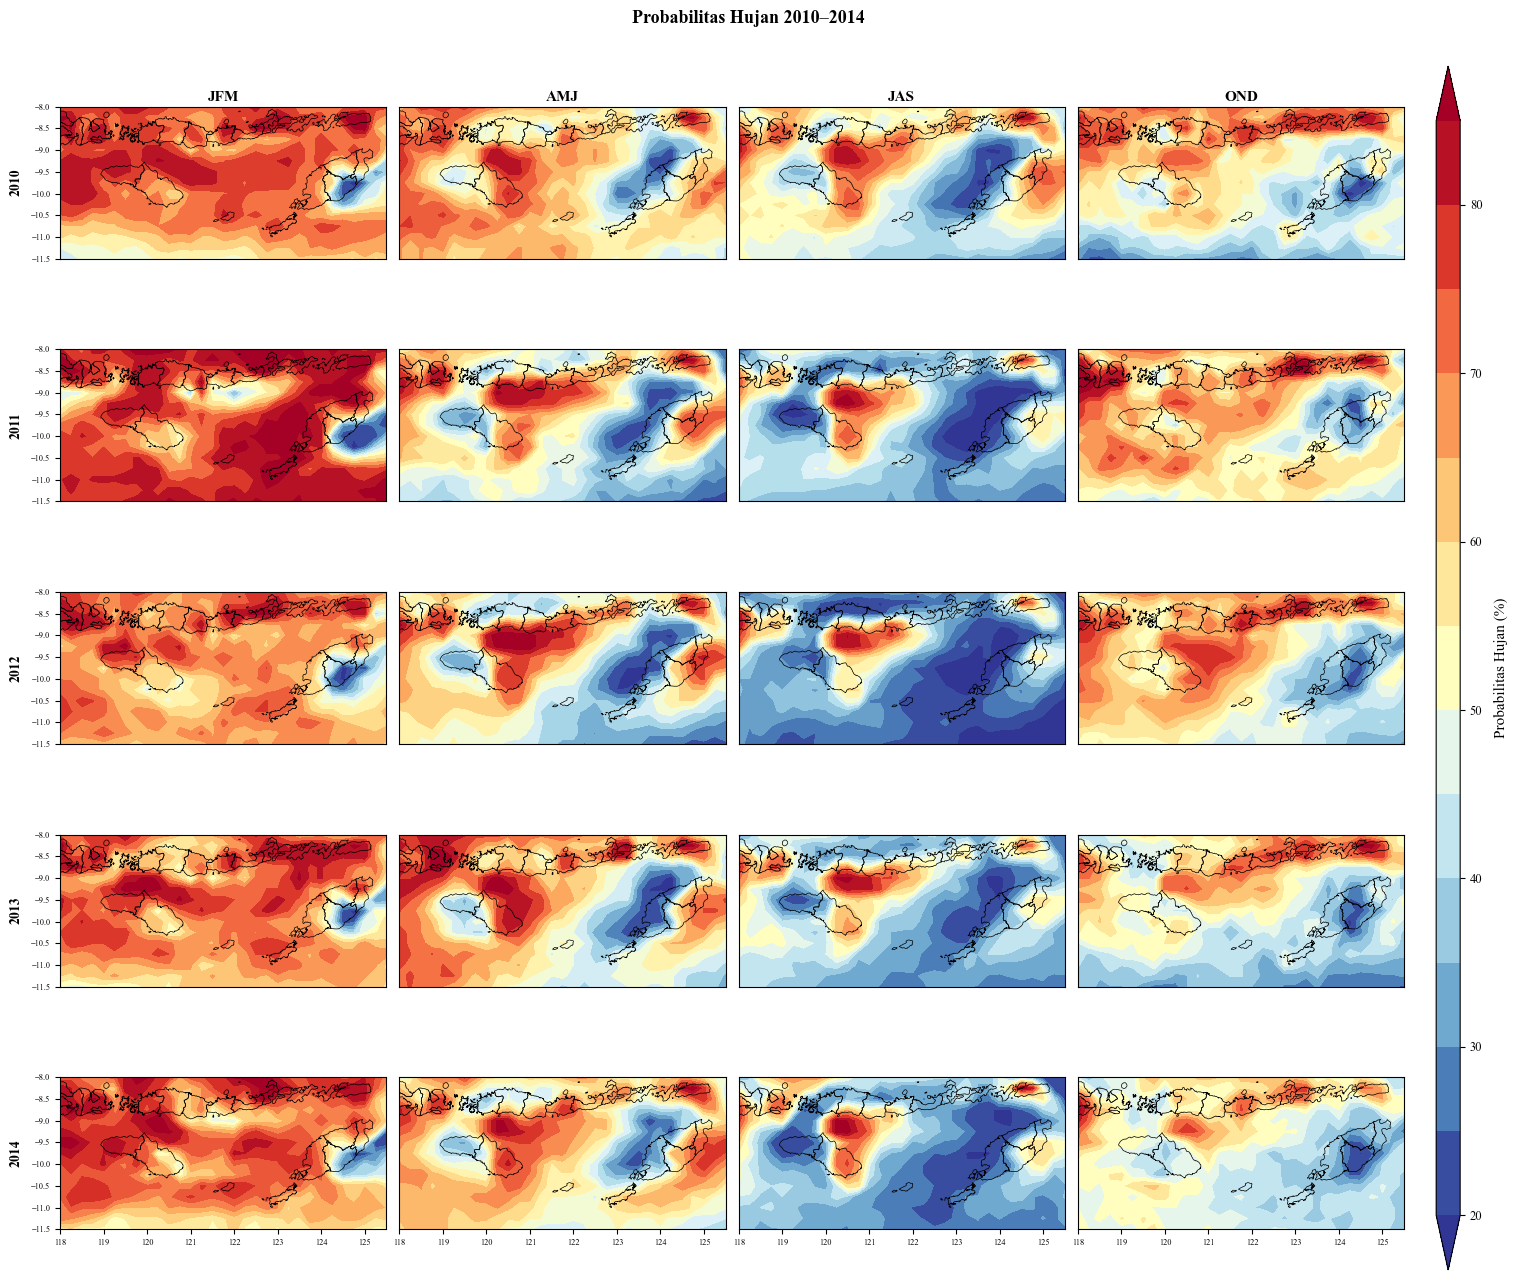

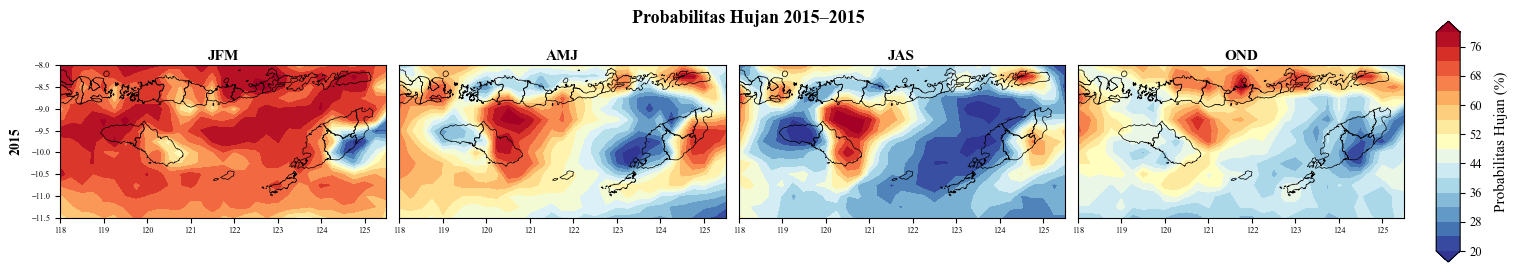

In [168]:
from shapely.geometry import Point
import matplotlib.pyplot as plt
import geopandas as gpd
import numpy as np

urutan_musim = ['JFM', 'AMJ', 'JAS', 'OND']

for frame in range(0, len(kombinasi), 20):
    subset_kombinasi = kombinasi[frame:frame+20]
    subset_kombinasi = sorted(
        subset_kombinasi,
        key=lambda x: (x[0], urutan_musim.index(x[1]))
    )

    # Ambil unik tahun dan musim dari subset ini
    tahun_list = sorted(set(x[0] for x in subset_kombinasi))
    musim_list = urutan_musim  # kolom: JFM, AMJ, JAS, OND

    nrows = len(tahun_list)   # baris = jumlah tahun
    ncols = len(musim_list)   # kolom = 4 musim

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(ncols * 4, nrows * 2.8)  # ukuran per panel
    )

    # Pastikan axes selalu 2D
    if nrows == 1:
        axes = axes[np.newaxis, :]
    if ncols == 1:
        axes = axes[:, np.newaxis]

    im = None  # untuk colorbar

    for row_idx, tahun in enumerate(tahun_list):
        for col_idx, musim in enumerate(musim_list):
            ax = axes[row_idx, col_idx]

            subset = spasial[
                (spasial['Year'] == tahun) &
                (spasial['Season'] == musim)
            ]

            if subset.empty:
                ax.set_visible(False)
                continue

            pivot = subset.pivot(
                index='latitude',
                columns='longitude',
                values='Hujan'
            ).sort_index()

            lon = pivot.columns.values
            lat = pivot.index.values
            Lon, Lat = np.meshgrid(lon, lat)
            Z = pivot.values

            im = ax.contourf(
                Lon, Lat, Z,
                levels=15,
                cmap='RdYlBu_r',
                extend='both'
            )
            indo.plot(
                ax=ax,
                color='none',
                edgecolor='black',
                linewidth=0.5
            )
            ax.set_xlim(lon.min(), lon.max())
            ax.set_ylim(lat.min(), lat.max())
            ax.margins(0)
            ax.set_aspect('equal')
            ax.tick_params(labelsize=6)

            # ── Label kolom (atas): nama musim ──
            if row_idx == 0:
                ax.set_title(musim, fontsize=11, fontweight='bold', pad=4)

            # ── Label baris (kiri): tahun ──
            if col_idx == 0:
                ax.set_ylabel(
                    str(tahun),
                    fontsize=10,
                    fontweight='bold',
                    rotation=90,
                    labelpad=6
                )
            else:
                ax.set_ylabel('')

            ax.set_xlabel('')

            # ── Tick: hanya tepi luar ──
            ax.tick_params(
                left=(col_idx == 0),
                bottom=(row_idx == nrows - 1),
                labelleft=(col_idx == 0),
                labelbottom=(row_idx == nrows - 1),
                labelsize=6
            )

    # ── Spacing rapat seperti referensi ──
    fig.subplots_adjust(
        left=0.07,
        right=0.91,
        top=0.94,
        bottom=0.08,
        wspace=0.04,   # jarak horizontal antar kolom (rapat)
        hspace=0.04    # jarak vertikal antar baris (rapat)
    )

    # ── Colorbar di kanan ──
    if im is not None:
        cax = fig.add_axes([0.93, 0.08, 0.015, 0.86])
        cbar = fig.colorbar(im, cax=cax)
        cbar.set_label('Probabilitas Hujan (%)', fontsize=11, labelpad=8)
        cbar.ax.tick_params(labelsize=9)

    # ── Judul utama frame ──
    tahun_awal = tahun_list[0]
    tahun_akhir = tahun_list[-1]
    fig.suptitle(
        f'Probabilitas Hujan {tahun_awal}–{tahun_akhir}',
        fontsize=13,
        fontweight='bold',
        y=0.98
    )

    plt.savefig(
        f'Frame_{frame//20 + 1}.png',
        dpi=300,
        bbox_inches='tight'
    )
    plt.show()

---
## Bagian 15: Ekspor Data Spasial untuk Dashboard

**Tujuan:** Menyimpan tabel `spasial` (probabilitas hujan per titik grid per tahun per musim) ke file CSV, yang akan digunakan sebagai sumber data utama untuk dashboard interaktif Streamlit.

File `spasial_data.csv` ini berisi semua informasi yang dibutuhkan dashboard:
- Koordinat titik grid (`latitude`, `longitude`)
- Tahun dan musim
- Nilai probabilitas hujan (%)

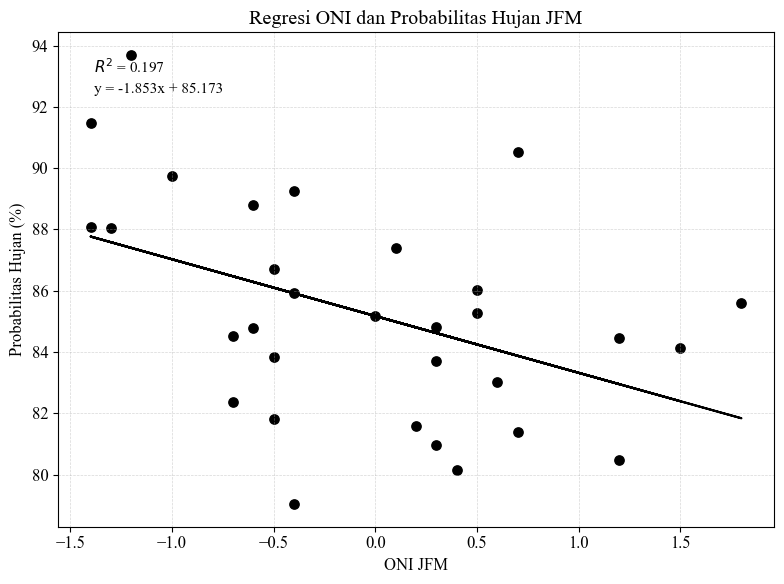

=== JFM ===
Persamaan Regresi : y = -1.853x + 85.173
R²                : 0.197
Kemiringan (a)    : -1.853
Intercept (b)     : 85.173



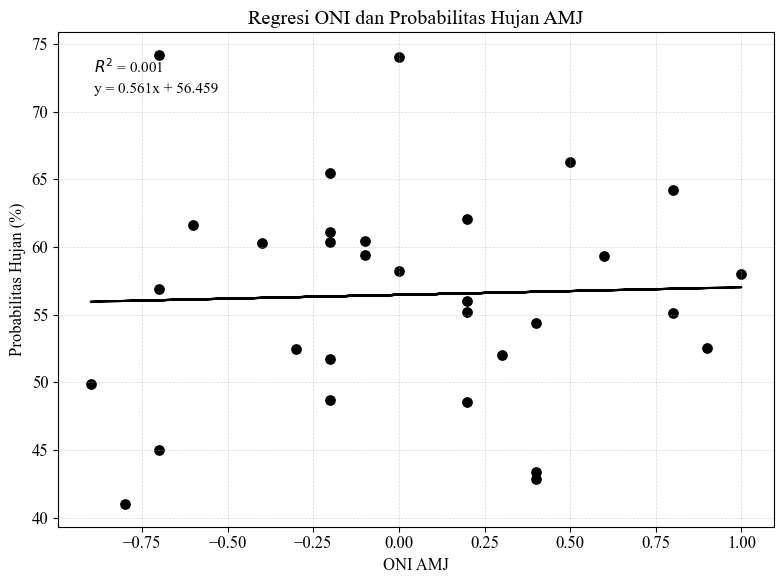

=== AMJ ===
Persamaan Regresi : y = 0.561x + 56.459
R²                : 0.001
Kemiringan (a)    : 0.561
Intercept (b)     : 56.459



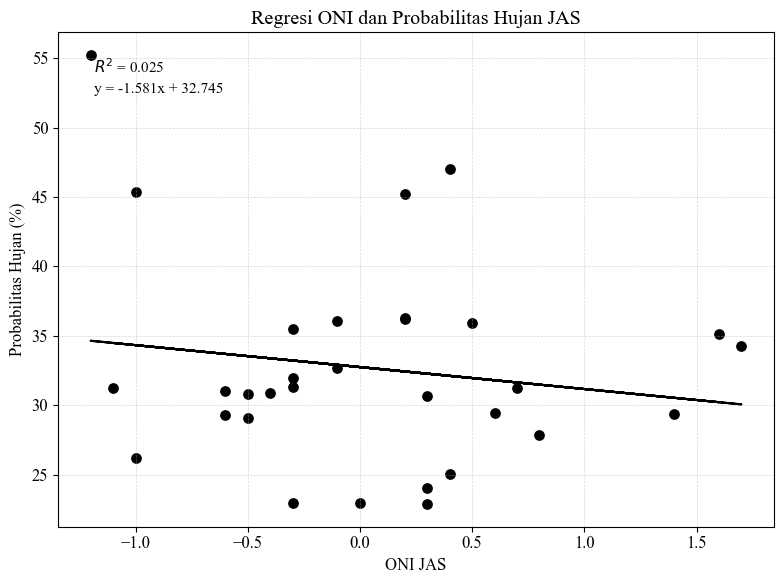

=== JAS ===
Persamaan Regresi : y = -1.581x + 32.745
R²                : 0.025
Kemiringan (a)    : -1.581
Intercept (b)     : 32.745



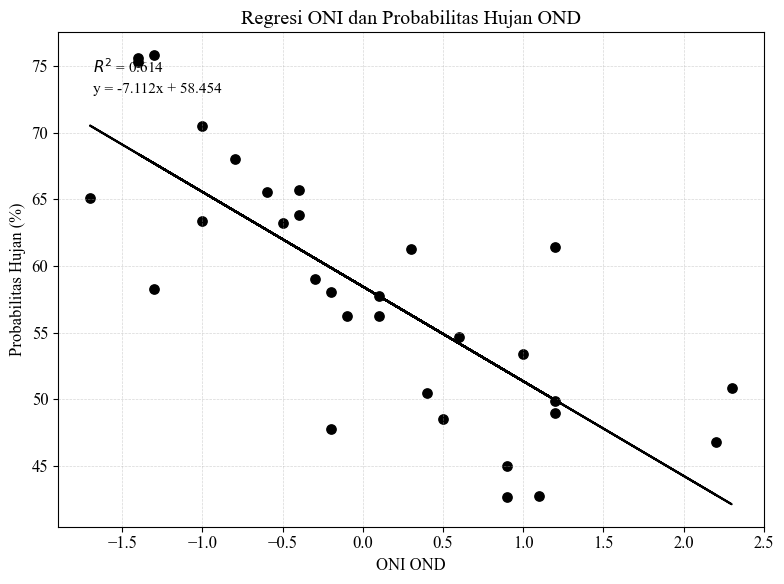

=== OND ===
Persamaan Regresi : y = -7.112x + 58.454
R²                : 0.614
Kemiringan (a)    : -7.112
Intercept (b)     : 58.454



In [169]:
# REGRESI ONI vs RATA-RATA PROBABILITAS HUJAN

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 12

rata_hujan = (
    spasial.groupby(['Year', 'Season'])['Hujan']
    .mean()
    .reset_index()
)


oni_long = dataONI.melt(
    id_vars='Year',
    value_vars=['JFM', 'AMJ', 'JAS', 'OND'],
    var_name='Season',
    value_name='ONI'
)

gabung_regresi = pd.merge(
    rata_hujan,
    oni_long,
    on=['Year', 'Season']
)


musim_list = ['JFM', 'AMJ', 'JAS', 'OND']


for musim in musim_list:

    subset = gabung_regresi[
        gabung_regresi['Season'] == musim
    ]

    X = subset[['ONI']]
    y = subset['Hujan']


    model = LinearRegression()
    model.fit(X, y)

    # Prediksi
    y_pred = model.predict(X)


    r2 = r2_score(y, y_pred)

    a = model.coef_[0]
    b = model.intercept_

    persamaan = f'y = {a:.3f}x + {b:.3f}'

    plt.figure(figsize=(8,6))

    # Scatter
    plt.scatter(
        X,
        y,
        color='black',
        s=45
    )

    # Garis regresi
    plt.plot(
        X,
        y_pred,
        color='black',
        linewidth=1.5
    )

    plt.text(
        0.05,
        0.95,
        f'$R^2$ = {r2:.3f}',
        transform=plt.gca().transAxes,
        fontsize=11,
        verticalalignment='top'
    )

    plt.text(
        0.05,
        0.90,
        persamaan,
        transform=plt.gca().transAxes,
        fontsize=11,
        verticalalignment='top'
    )

    plt.title(
        f'Regresi ONI dan Probabilitas Hujan {musim}'
    )

    plt.xlabel(
        f'ONI {musim}'
    )

    plt.ylabel(
        'Probabilitas Hujan (%)'
    )

    plt.grid(
        linestyle='--',
        linewidth=0.5,
        alpha=0.5
    )

    plt.tight_layout()
    plt.show()

    print(f'=== {musim} ===')
    print(f'Persamaan Regresi : {persamaan}')
    print(f'R²                : {r2:.3f}')
    print(f'Kemiringan (a)    : {a:.3f}')
    print(f'Intercept (b)     : {b:.3f}')
    print()

In [170]:

# Ekspor ke folder dataset untuk dashboard
spasial.to_csv('spasial_data.csv', index=False)
print("Data berhasil diekspor untuk Dashboard!")

Data berhasil diekspor untuk Dashboard!
